<a href="https://colab.research.google.com/github/MSGamgee85/MSGamgee85/blob/main/EGF_13_Lista_Ex_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Exercício 4**
---

**Equação Diferencial Parcial de Transporte**


$\boxed{\dfrac{\partial \phi}{\partial t}+c\dfrac{\partial \phi}{\partial x}= 0}$



$\bullet$ modela escoamento de massa

$\bullet$  $\phi = \phi(t, x)$

$\bullet$ $c\dfrac{\Delta t}{\Delta x}$ =  número de Courant; de forma simplificada representa o **fluxo de massa (informação/velocidade)** em um fluido. Valores diferentes desse número indica se o sistema é estático, estável ou instável.

---

**Leitura do código**. Cada item é dividido em duas partes. Na primeira apresentamos os cálculos e tabelas de dados que são posteriormente utilizados na segunda parte onde fazemos a geração dos gráficos tridimensionais.

---

---
### **Item a)**
---

In [ ]:
# -- Geração da tabela de dados -- #

# Bibliotecas utilizadas
import pandas as pd   # estruturas tabulares de dados
import numpy as np    # funções matemáticas e operações com vetores e matrizes

# Parâmetros do problema
dx = 0.1
dt = 0.1
c = 1.0
x = np.arange(0, 0.6, dx) # contagem em Python termina em n-1
t = np.arange(0, 0.6, dt)
C = c * dt / dx # número de Courant

# Inicia matriz de resultados (linhas = tempo, colunas = espaço)
phi = np.ones((len(t), len(x))) # phi tem valor constante = 1.0

# DataFrame para exibição
df_a = pd.DataFrame(phi, index=[f't={round(i,1)}' for i in t],
                    columns=[f'x={round(j,1)}' for j in x])

print("Tabela Item a (c=1) → Solução Constante")
print("-"*48)
display(df_a)

Tabela Item a (c=1) → Solução Constante
------------------------------------------------


,x=0.0,x=0.1,x=0.2,x=0.3,x=0.4,x=0.5
t=0.0,1.0,1.0,1.0,1.0,1.0,1.0
t=0.1,1.0,1.0,1.0,1.0,1.0,1.0
t=0.2,1.0,1.0,1.0,1.0,1.0,1.0
t=0.3,1.0,1.0,1.0,1.0,1.0,1.0
t=0.4,1.0,1.0,1.0,1.0,1.0,1.0
t=0.5,1.0,1.0,1.0,1.0,1.0,1.0


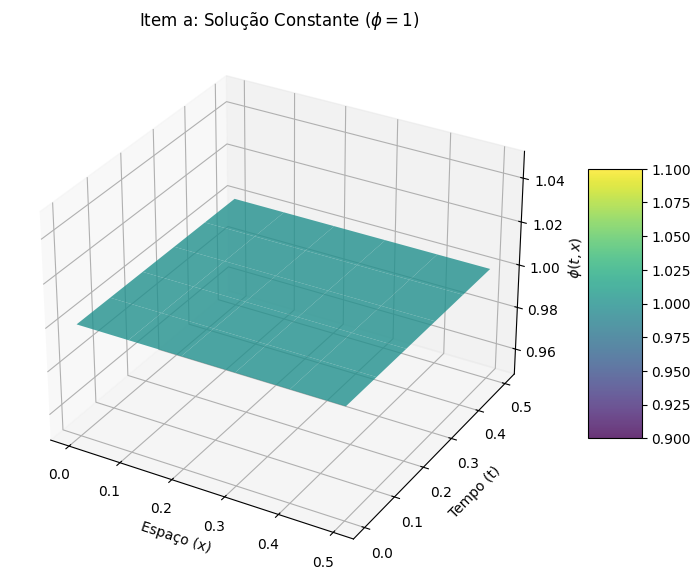

In [ ]:
# -- Geração do gráfico da solução --#

# Bibliotecas utilizadas
import numpy as np
import matplotlib.pyplot as plt   # geração de gráficos e visualizações
import warnings
warnings.filterwarnings('ignore') # ignora avisos e alertas

# Parâmetros do problema
L = 0.5        # Limite de x
T = 0.5        # Limite de t
dx = 0.1
dt = 0.1
c = 1.0
C = c * dt / dx # Número de Courant

# Criação da malha (grid)
x = np.arange(0, L + dx, dx)
t = np.arange(0, T + dt, dt)
X, T = np.meshgrid(x, t)

# Inicia matriz de resultados (linhas = tempo, colunas = espaço)
phi = np.zeros((len(t), len(x)))

# Condição Inicial:
phi[0, :] = 1.0

# Aplicamos a aproximação simétrica para gerar os pontos
for j in range(0, len(t) - 1):
    for i in range(1, len(x)):
        phi[j+1, i] = phi[j, i] - C * (phi[j, i] - phi[j, i-1])

    # Condições de Contorno:
    phi[j+1, -1] = 1.0
    phi[j+1, 0] = 1.0

# Plotagem 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, T, phi, cmap='viridis', edgecolor='none', alpha = 0.8)

ax.set_xlabel('Espaço (x)')
ax.set_ylabel('Tempo (t)')
ax.set_zlabel('$\phi(t, x)$')
ax.set_title('Item a: Solução Constante ($\phi = 1$)')

plt.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.show()

---

**Comentário**: a solução é **estática**, representada por uma superfície de altura constante.

---

---
### **Item b)**
---

In [ ]:
# -- Geração da tabela de dados -- #

# Bibliotecas utilizadas
import pandas as pd
import numpy as np

# Parâmetros do problema
dx, dt, c = 0.1, 0.1, 0.1
x = np.round(np.arange(0, 0.6, dx), 1)
t = np.round(np.arange(0, 0.6, dt), 1)
C = c * dt / dx

# Inicia matriz de resultados (linhas = tempo, colunas = espaço)
phi = np.zeros((len(t), len(x)))

# Condição inicial:
phi[0, :] = x

# Aplicamos a aproximação simétrica para gerar os pontos
for j in range(0, len(t) - 1):
    for i in range(1, len(x)):
        phi[j+1, i] = phi[j, i] - C * (phi[j, i] - phi[j, i-1])
    phi[j+1, -1] = 1.0 # Condição de contorno fixa em x=0.5

df_b = pd.DataFrame(phi, index=[f't={i}' for i in t],
                    columns=[f'x={j}' for j in x])

print("Tabela Item b (c=0.1) → Solução Estável - Nível acima")
print("-"*54)
display(df_b.round(4))

Tabela Item b (c=0.1) → Solução Estável - Nível acima
------------------------------------------------------


,x=0.0,x=0.1,x=0.2,x=0.3,x=0.4,x=0.5
t=0.0,0.0,0.1000,0.2000,0.30,0.40,0.5
t=0.1,0.0,0.0900,0.1900,0.29,0.39,1.0
t=0.2,0.0,0.0810,0.1800,0.28,0.38,1.0
t=0.3,0.0,0.0729,0.1701,0.27,0.37,1.0
t=0.4,0.0,0.0656,0.1604,0.26,0.36,1.0
t=0.5,0.0,0.0590,0.1509,0.25,0.35,1.0


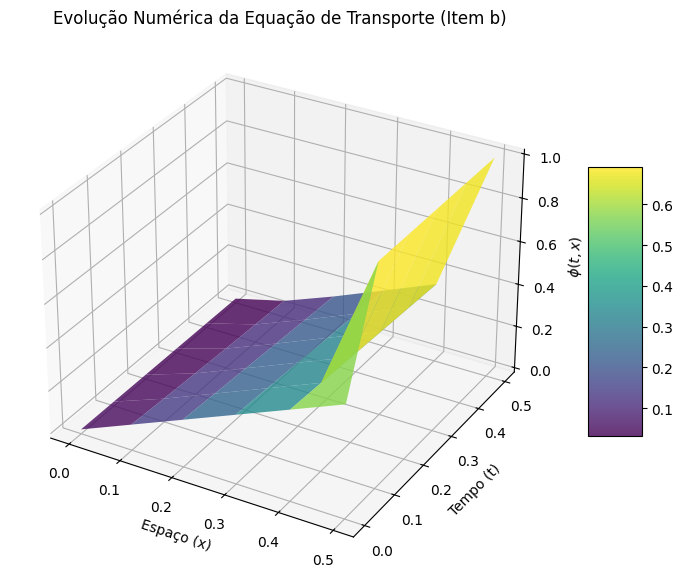

In [ ]:
# -- Geração do gráfico da solução -- #

# Bibliotecas utilizadas
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Parâmetros do problema
L = 0.5        # Limite de x
T = 0.5        # Limite de t
dx = 0.1
dt = 0.1
c = 0.1
C = c * dt / dx # Número de Courant (0.1)

# Criação da malha (grid)
x = np.arange(0, L + dx, dx)
t = np.arange(0, T + dt, dt)
X, T = np.meshgrid(x, t)

# Inicia matriz de resultados (linhas = tempo, colunas = espaço)
phi = np.zeros((len(t), len(x)))

# Condição Inicial:
phi[0, :] = x

# Aplicamos a aproximação simétrica para gerar os pontos
for j in range(0, len(t) - 1):
    for i in range(1, len(x)):
        phi[j+1, i] = phi[j, i] - C * (phi[j, i] - phi[j, i-1])

    # Forçamos a condição de contorno em x=0.5 (última coluna) para t > 0
    phi[j+1, -1] = 1.0

# Plotagem 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, T, phi, cmap='viridis', edgecolor='none', alpha=0.8)

ax.set_xlabel('Espaço (x)')
ax.set_ylabel('Tempo (t)')
ax.set_zlabel('$\phi(t, x)$')
ax.set_title('Evolução Numérica da Equação de Transporte (Item b)')

plt.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.show()

---

**Comentário**: temos uma solução **estável**, escoamento em nível acima.

---

---
### **Item c.1)**
---

In [ ]:
# -- Geração da tabela de dados -- #

# Bibliotecas utilizadas
import pandas as pd
import numpy as np

# Parâmetros do problema
c = 3.0
C = c * 0.1 / 0.1   # número de Courant

# Inicia matriz de resultados (linhas = tempo, colunas = espaço)
phi = np.zeros((len(t), len(x)))

# Condições iniciais
phi[0, :] = [(-1)**i for i in range(len(x))]

# Aplicamos a aproximação simétrica para gerar os pontos
for j in range(0, len(t) - 1):
    for i in range(1, len(x)):
        phi[j+1, i] = phi[j, i] - C * (phi[j, i] - phi[j, i-1])
        # Forçamos a condição de contorno em x=0.5 (última coluna) para t > 0
        phi[j+1, -1] = 1.0

df_c1 = pd.DataFrame(phi, index=[f't={round(i,1)}' for i in t],
                     columns=[f'x={round(j,1)}' for j in x])

print("Tabela Item c.1 (c=3) → Instável - Explosão numérica")
print("-"*52)
display(df_c1)

Tabela Item c.1 (c=3) → Instável - Explosão numérica
----------------------------------------------------


,x=0.0,x=0.1,x=0.2,x=0.3,x=0.4,x=0.5
t=0.0,1.0,-1.0,1.0,-1.0,1.0,-1.0
t=0.1,0.0,5.0,-5.0,5.0,-5.0,1.0
t=0.2,0.0,-10.0,25.0,-25.0,25.0,1.0
t=0.3,0.0,20.0,-80.0,125.0,-125.0,1.0
t=0.4,0.0,-40.0,220.0,-490.0,625.0,1.0
t=0.5,0.0,80.0,-560.0,1640.0,-2720.0,1.0


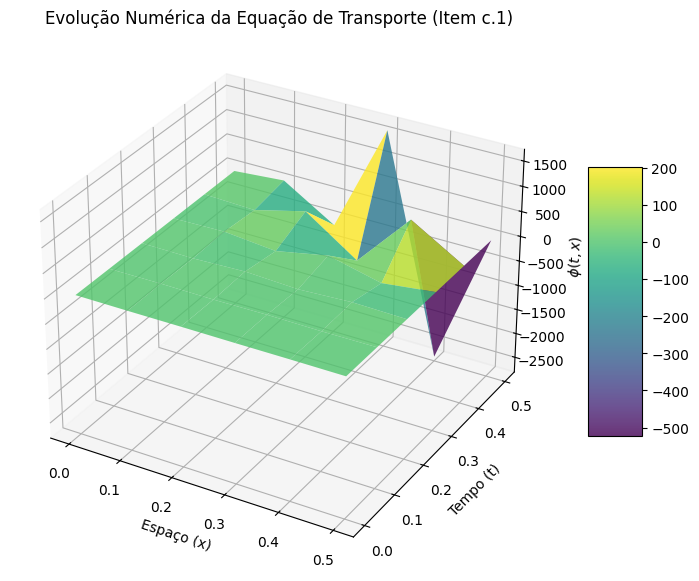

In [ ]:
# -- Geração do gráfico da solução -- #

# Bibliotecas utilizadas
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Parâmetros do problema
L = 0.5        # Limite de x
T = 0.5        # Limite de t
dx = 0.1
dt = 0.1
c = 3.0
C = c * dt / dx # Número de Courant (0.1)

# Criação da malha (grid)
x = np.arange(0, L + dx, dx)
t = np.arange(0, T + dt, dt)
X, T = np.meshgrid(x, t)

# Inicia matriz de resultados (linhas = tempo, colunas = espaço)
phi = np.zeros((len(t), len(x)))

# Condição Inicial:
phi[0, :] = [(-1)**i for i in range(len(x))]

# Aplicamos a aproximação simétrica para gerar os pontos
for j in range(0, len(t) - 1):
    for i in range(1, len(x)):
        phi[j+1, i] = phi[j, i] - C * (phi[j, i] - phi[j, i-1])

    # Forçamos a condição de contorno em x=0.5 (última coluna) para t > 0
    phi[j+1, -1] = 1.0

# Plotagem 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, T, phi, cmap='viridis', edgecolor='none', alpha=0.8)

ax.set_xlabel('Espaço (x)')
ax.set_ylabel('Tempo (t)')
ax.set_zlabel('$\phi(t, x)$')
ax.set_title('Evolução Numérica da Equação de Transporte (Item c.1)')

plt.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.show()

---

**Comentário**: solução **instável**, representada por picos e vales que aumentam indefinidamente <u> (explosão numérica)</u>.

---

---
### **Item c.2)**
---

In [ ]:
# -- Geração da tabela de dados -- #

# Bibliotecas utilizadas
import pandas as pd
import numpy as np

# Parâmetros
dx, dt, c = 0.1, 0.1, 0.1
x = np.arange(0, 0.6, dx)
t = np.arange(0, 0.6, dt)
C = c * dt / dx

# Inicia matriz de resultados (linhas = tempo, colunas = espaço)
phi = np.zeros((len(t), len(x)))

# Condição inicial:
phi[0, :] = [(-1)**i for i in range(len(x))]

# Aplicamos a aproximação simétrica para gerar os pontos
for j in range(0, len(t) - 1):
    for i in range(1, len(x)):
        phi[j+1, i] = phi[j, i] - C * (phi[j, i] - phi[j, i-1])
    # Forçamos a condição de contorno
    phi[j+1, -1] = 1.0

df_c2 = pd.DataFrame(phi, index=[f't={round(i,1)}' for i in t],
                     columns=[f'x={round(j,1)}' for j in x])

print("Tabela Item c.2 (c=0.1) → Estável com amortecimento")
print("-"*52)
display(df_c2.round(4))

Tabela Item c.2 (c=0.1) → Estável com amortecimento
----------------------------------------------------


,x=0.0,x=0.1,x=0.2,x=0.3,x=0.4,x=0.5
t=0.0,1.0,-1.0000,1.0000,-1.0000,1.0000,-1.0
t=0.1,0.0,-0.8000,0.8000,-0.8000,0.8000,1.0
t=0.2,0.0,-0.7200,0.6400,-0.6400,0.6400,1.0
t=0.3,0.0,-0.6480,0.5040,-0.5120,0.5120,1.0
t=0.4,0.0,-0.5832,0.3888,-0.4104,0.4096,1.0
t=0.5,0.0,-0.5249,0.2916,-0.3305,0.3276,1.0


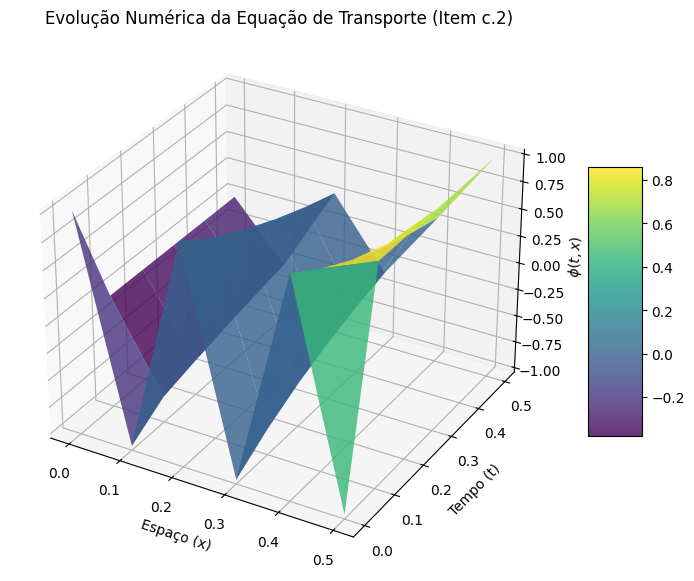

In [ ]:
# -- Geração do gráfico da solução -- #

# Bibliotecas utilizadas
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Parâmetros do problema
L = 0.5        # Limite de x
T_final = 0.5  # Limite de t
dx = 0.1
dt = 0.1
c = 0.1
C = c * dt / dx # Número de Courant (0.1)

# Criação da malha (grid)
x = np.arange(0, L + dx, dx)
t = np.arange(0, T_final + dt, dt)
X, T = np.meshgrid(x, t)

# Inicia matriz de resultados (linhas = tempo, colunas = espaço)
phi = np.zeros((len(t), len(x)))

# Condição Inicial:
phi[0, :] = [(-1)**i for i in range(len(x))]

# Aplicamos a aproximação simétrica para gerar os pontos
for j in range(0, len(t) - 1):
    for i in range(1, len(x)):
        phi[j+1, i] = phi[j, i] - C * (phi[j, i] - phi[j, i-1])

    # Forçamos a condição de contorno em x=0.5 (última coluna) para t > 0
    phi[j+1, -1] = 1.0

# Plotagem 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, T, phi, cmap='viridis', edgecolor='none', alpha=0.8)

ax.set_xlabel('Espaço (x)')
ax.set_ylabel('Tempo (t)')
ax.set_zlabel('$\phi(t, x)$')
ax.set_title('Evolução Numérica da Equação de Transporte (Item c.2)')

plt.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.show()

---

**Comentário**: solução **estável** (com *amortecimento*), picos e vales decrescem com o passar do tempo atingindo plano de equilíbrio.

---

---
### **Tabelas Consolidadas**
---

In [ ]:
# -- Exibição de todas as tabelas de dados -- #

import pandas as pd # Importar pandas novamente para garantir, embora já esteja no kernel

print("Tabela Item a (c=1) → Solução Constante")
print("-"*50)
display(df_a)

print("\nTabela Item b (c=0.1) → Estável - Nível acima")
print("-"*50)
display(df_b.round(4))

print("\nTabela Item c.1 (c=3) → Instável - Explosão numérica")
print("-"*52)
display(df_c1)

print("\nTabela Item c.2 (c=0.1) → Estável com amortecimento")
print("-"*52)
display(df_c2.round(4))

Tabela Item a (c=1) → Solução Constante
--------------------------------------------------


,x=0.0,x=0.1,x=0.2,x=0.3,x=0.4,x=0.5
t=0.0,1.0,1.0,1.0,1.0,1.0,1.0
t=0.1,1.0,1.0,1.0,1.0,1.0,1.0
t=0.2,1.0,1.0,1.0,1.0,1.0,1.0
t=0.3,1.0,1.0,1.0,1.0,1.0,1.0
t=0.4,1.0,1.0,1.0,1.0,1.0,1.0
t=0.5,1.0,1.0,1.0,1.0,1.0,1.0



Tabela Item b (c=0.1) → Estável - Nível acima
--------------------------------------------------


,x=0.0,x=0.1,x=0.2,x=0.3,x=0.4,x=0.5
t=0.0,0.0,0.1000,0.2000,0.30,0.40,0.5
t=0.1,0.0,0.0900,0.1900,0.29,0.39,1.0
t=0.2,0.0,0.0810,0.1800,0.28,0.38,1.0
t=0.3,0.0,0.0729,0.1701,0.27,0.37,1.0
t=0.4,0.0,0.0656,0.1604,0.26,0.36,1.0
t=0.5,0.0,0.0590,0.1509,0.25,0.35,1.0



Tabela Item c.1 (c=3) → Instável - Explosão numérica
----------------------------------------------------


,x=0.0,x=0.1,x=0.2,x=0.3,x=0.4,x=0.5
t=0.0,1.0,-1.0,1.0,-1.0,1.0,-1.0
t=0.1,0.0,5.0,-5.0,5.0,-5.0,1.0
t=0.2,0.0,-10.0,25.0,-25.0,25.0,1.0
t=0.3,0.0,20.0,-80.0,125.0,-125.0,1.0
t=0.4,0.0,-40.0,220.0,-490.0,625.0,1.0
t=0.5,0.0,80.0,-560.0,1640.0,-2720.0,1.0



Tabela Item c.2 (c=0.1) → Estável com amortecimento
----------------------------------------------------


,x=0.0,x=0.1,x=0.2,x=0.3,x=0.4,x=0.5
t=0.0,1.0,-1.0000,1.0000,-1.0000,1.0000,-1.0
t=0.1,0.0,-0.8000,0.8000,-0.8000,0.8000,1.0
t=0.2,0.0,-0.7200,0.6400,-0.6400,0.6400,1.0
t=0.3,0.0,-0.6480,0.5040,-0.5120,0.5120,1.0
t=0.4,0.0,-0.5832,0.3888,-0.4104,0.4096,1.0
t=0.5,0.0,-0.5249,0.2916,-0.3305,0.3276,1.0


---
### **Gráficos Consolidados**
---

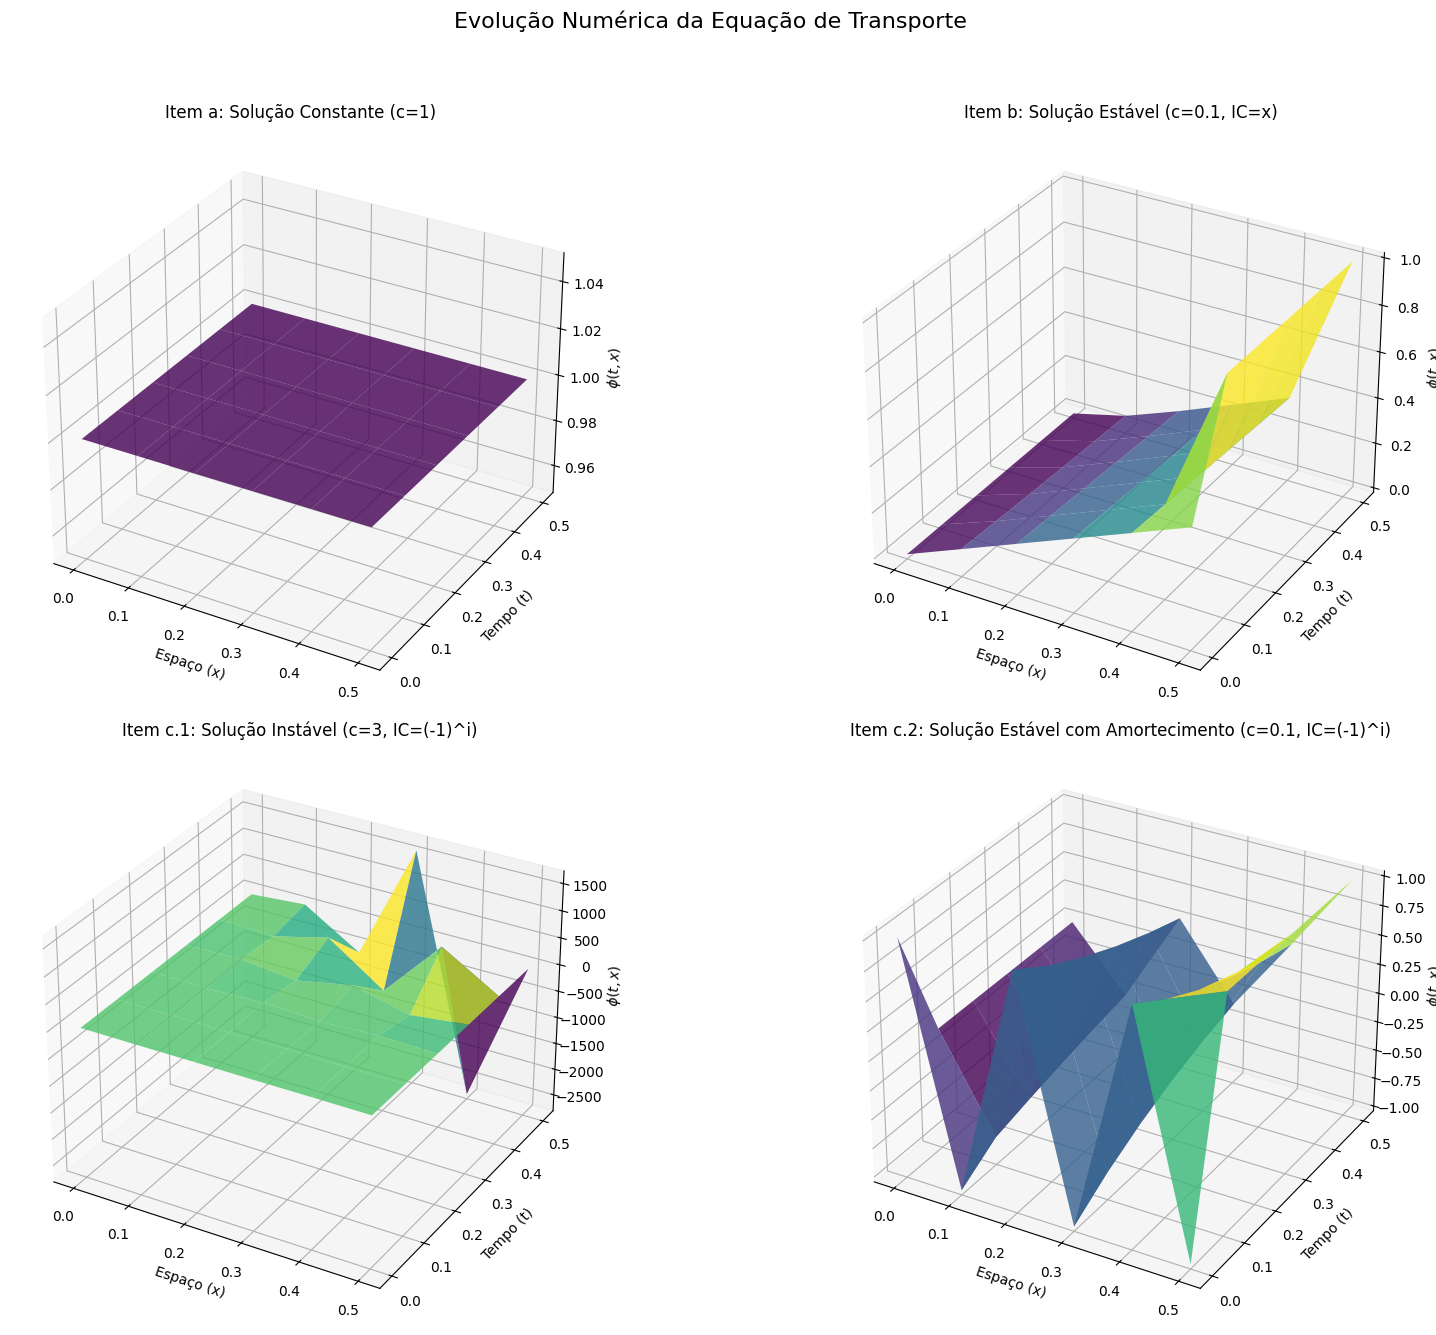

In [ ]:
# -- Geração de uma figura com todos os 4 gráficos -- #

import numpy as np     # funções matemáticas e operações com vetores e matrizes
import matplotlib.pyplot as plt # geração de gráficos e visualizações
import warnings
warnings.filterwarnings('ignore') # ignora avisos e alertas

# Parâmetros comuns
L = 0.5
T = 0.5
dx = 0.1
dt = 0.1

# Gera a grade de pontos
x = np.arange(0, L + dx, dx)
t = np.arange(0, T + dt, dt)
X_mesh, T_mesh = np.meshgrid(x, t)

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Evolução Numérica da Equação de Transporte', fontsize=16)

# --- Item a ---
ax1 = fig.add_subplot(2, 2, 1, projection='3d')

c_a = 1.0
C_a = c_a * dt / dx
phi_a = np.zeros((len(t), len(x)))
phi_a[0, :] = 1.0
for j in range(0, len(t) - 1):
    for i in range(1, len(x)):
        phi_a[j+1, i] = phi_a[j, i] - C_a * (phi_a[j, i] - phi_a[j, i-1])
    # Forçamos as condições de contorno
    phi_a[j+1, -1] = 1.0
    phi_a[j+1, 0] = 1.0

surf1 = ax1.plot_surface(X_mesh, T_mesh, phi_a, cmap='viridis', edgecolor='none', alpha=0.8)
ax1.set_title('Item a: Solução Constante (c=1)')
ax1.set_xlabel('Espaço (x)')
ax1.set_ylabel('Tempo (t)')
ax1.set_zlabel('$\phi(t, x)$')
# fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=5)

# --- Item b ---
ax2 = fig.add_subplot(2, 2, 2, projection='3d')

c_b = 0.1
C_b = c_b * dt / dx
phi_b = np.zeros((len(t), len(x)))
phi_b[0, :] = x
for j in range(0, len(t) - 1):
    for i in range(1, len(x)):
        phi_b[j+1, i] = phi_b[j, i] - C_b * (phi_b[j, i] - phi_b[j, i-1])
    phi_b[j+1, -1] = 1.0

surf2 = ax2.plot_surface(X_mesh, T_mesh, phi_b, cmap='viridis', edgecolor='none', alpha=0.8)
ax2.set_title('Item b: Solução Estável (c=0.1, IC=x)')
ax2.set_xlabel('Espaço (x)')
ax2.set_ylabel('Tempo (t)')
ax2.set_zlabel('$\phi(t, x)$')
# fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=5)

# --- Item c.1 ---
ax3 = fig.add_subplot(2, 2, 3, projection='3d')

c_c1 = 3.0
C_c1 = c_c1 * dt / dx
phi_c1 = np.zeros((len(t), len(x)))
phi_c1[0, :] = [(-1)**i for i in range(len(x))]
for j in range(0, len(t) - 1):
    for i in range(1, len(x)):
        phi_c1[j+1, i] = phi_c1[j, i] - C_c1 * (phi_c1[j, i] - phi_c1[j, i-1])
    phi_c1[j+1, -1] = 1.0

surf3 = ax3.plot_surface(X_mesh, T_mesh, phi_c1, cmap='viridis', edgecolor='none', alpha=0.8)
ax3.set_title('Item c.1: Solução Instável (c=3, IC=(-1)^i)')
ax3.set_xlabel('Espaço (x)')
ax3.set_ylabel('Tempo (t)')
ax3.set_zlabel('$\phi(t, x)$')
# fig.colorbar(surf3, ax=ax3, shrink=0.5, aspect=5)

# --- Item c.2 ---
ax4 = fig.add_subplot(2, 2, 4, projection='3d')

c_c2 = 0.1
C_c2 = c_c2 * dt / dx
phi_c2 = np.zeros((len(t), len(x)))
phi_c2[0, :] = [(-1)**i for i in range(len(x))]
for j in range(0, len(t) - 1):
    for i in range(1, len(x)):
        phi_c2[j+1, i] = phi_c2[j, i] - C_c2 * (phi_c2[j, i] - phi_c2[j, i-1])
    phi_c2[j+1, -1] = 1.0

surf4 = ax4.plot_surface(X_mesh, T_mesh, phi_c2, cmap='viridis', edgecolor='none', alpha=0.8)
ax4.set_title('Item c.2: Solução Estável com Amortecimento (c=0.1, IC=(-1)^i)')
ax4.set_xlabel('Espaço (x)')
ax4.set_ylabel('Tempo (t)')
ax4.set_zlabel('$\phi(t, x)$')
# fig.colorbar(surf4, ax=ax4, shrink=0.5, aspect=5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta layout para evitar sobreposição
plt.show()